In [121]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import glob
import os

pd.set_option("display.max_columns", None)  # no column truncation
pd.set_option("display.width", 0)  # prevents line wrapping

In [122]:
folder_path = "../data/"
all_files = glob.glob(os.path.join(folder_path, "*.csv"))
df_list = [pd.read_csv(f) for f in all_files]
df = pd.concat(df_list, ignore_index=True)
df.columns = [
    "DIA",
    "MES",
    "ANO",
    "ADUANA",
    "NUMERO DE ACEPTACION",
    "RUT PROBABLE IMPORTADOR",
    "DIGITO VERIFICADOR RUT",
    "PROBABLE IMPORTADOR",
    "PARTIDA ARANCELARIA",
    "PRODUCTO",
    "MARCA",
    "VARIEDAD",
    "DESCRIPCION",
    "PAIS DE ORIGEN",
    "PAIS DE ADQUISICION",
    "VIA DE TRANSPORTE",
    "FORMA PAGO",
    "PUERTO DE EMBARQUE",
    "PUERTO DE DESEMBARQUE",
    "COMPANIA DE TRANSPORTE",
    "TIPO DE CARGA",
    "TIPO DE BULTO",
    "PESO BRUTO TOTAL",
    "CLAUSULA",
    "IMPUESTO",
    "CANTIDAD",
    "UNIDAD",
    "US$ FOB",
    "US$ FLETE",
    "US$ SEGURO",
    "US$ CIF",
    "US$ CIF UNIT",
    "TIPO DE OPERACION",
    "DESCRIPCION ARANCELARIA",
    "NUM DE ITEM",
    "PAIS COMPANIA DE TRANSPORTE",
    "IMPUESTO US$",
    "CANTIDAD DE BULTO",
    "ZONA ECONOMICA",
    "CLAVE ECONOMICA IMPORTADOR",
    "ALMACEN",
    "FECHA DE ALMACEN",
    "NRO DE MANIFIESTO",
    "FECHA DE MANIFIESTO",
    "NRO DOC. TRANSPORTE",
    "FECHA DOC. TRANSPORTE",
    "ITEMS TOTALES",
    "FOB TOTAL",
    "FLETE TOTAL",
    "SEGURO TOTAL",
    "CIF TOTAL",
    "TOTAL IVA",
    "US$ FOB UNIT",
    "ACUERDO COMERCIAL",
    "CANTIDAD UNIDADES FISICAS",
    "UNIDAD DE MEDIDA FISICA",
    "ESTADO DE MERCANCIA",
    "EMISOR",
]
containers = [
    "CONTENEDOR 20",
    "CONTENEDOR 40",
    "CONTENEDOR REFRIGERADO 40",
    "CONTENEDOR NO REFRIGERADO",
    "CONTENEDOR REFRIGERADO 20",
]
df = df[df["TIPO DE BULTO"].isin(containers)].copy()
df["CANTIDAD DE BULTO"] = df["CANTIDAD DE BULTO"].fillna(1)
df["CANTIDAD DE BULTO"] = df["CANTIDAD DE BULTO"].astype(int)
df["CANTIDAD DE BULTO"] = np.where(df["TIPO DE BULTO"].str.contains("40"), 2, 1)
df.rename(columns={"DIA": "day", "MES": "month", "ANO": "year"}, inplace=True)
df["FECHA"] = pd.to_datetime(df[["year", "month", "day"]], errors="raise")
df["FECHA_TRANS"] = pd.to_datetime(
    df["FECHA DOC. TRANSPORTE"], format="%d%m%Y", errors="coerce"
)
df["DIFF_DAYS"] = (df["FECHA"] - df["FECHA_TRANS"]).dt.days
df["FOB_POR_BULTO"] = df["FOB TOTAL"] / df["CANTIDAD DE BULTO"]
df["FLETE_POR_BULTO"] = df["FLETE TOTAL"] / df["CANTIDAD DE BULTO"]
df["SEGURO_POR_BULTO"] = df["SEGURO TOTAL"] / df["CANTIDAD DE BULTO"]

df["PESO BRUTO POR CONTENEDOR"] = df["PESO BRUTO TOTAL"] / df["CANTIDAD DE BULTO"]
df["ITEMS POR CONTENEDOR"] = df["ITEMS TOTALES"] / df["CANTIDAD DE BULTO"]

df = df.drop(
    columns=[
        "ADUANA",
        "DIGITO VERIFICADOR RUT",
        "PROBABLE IMPORTADOR",
        "PRODUCTO",
        "MARCA",
        "VARIEDAD",
        "DESCRIPCION",
        "VIA DE TRANSPORTE",
        "DESCRIPCION ARANCELARIA",
        "NUM DE ITEM",
        "FORMA PAGO",
        "TIPO DE CARGA",
        "TIPO DE OPERACION",
        "PAIS COMPANIA DE TRANSPORTE",
        "ALMACEN",
        "ZONA ECONOMICA",
        "CLAVE ECONOMICA IMPORTADOR",
        "ACUERDO COMERCIAL",
        "EMISOR",
        "ESTADO DE MERCANCIA",
        "NRO DOC. TRANSPORTE",
        "FECHA DE MANIFIESTO",
        "FECHA DE ALMACEN",
        "FECHA DOC. TRANSPORTE",
        "NRO DE MANIFIESTO",
        "IMPUESTO US$",
        "IMPUESTO US$",
        "IMPUESTO",
        "TOTAL IVA",
        "PARTIDA ARANCELARIA",
    ]
)
df = df.drop(
    columns=[
        "CIF TOTAL",
        "US$ CIF",
        "US$ CIF UNIT",
        "US$ FOB UNIT",
        "CANTIDAD",
        "US$ FOB",
        "US$ FLETE",
        "US$ SEGURO",
        "PAIS DE ADQUISICION",
        "FOB TOTAL",
        "FLETE TOTAL",
        "SEGURO TOTAL",
        "PESO BRUTO TOTAL",
        "UNIDAD",
        "ITEMS TOTALES",
        "day",
        "month",
        "year",
    ]
)
df.head()

/var/folders/dy/8nkgqf653sggg31kzy33mjdr0000gn/T/ipykernel_68214/2345102473.py:3: DtypeWarning: Columns (5) have mixed types. Specify dtype option on import or set low_memory=False.
  df_list = [pd.read_csv(f) for f in all_files]
/var/folders/dy/8nkgqf653sggg31kzy33mjdr0000gn/T/ipykernel_68214/2345102473.py:3: DtypeWarning: Columns (5,6,40,42) have mixed types. Specify dtype option on import or set low_memory=False.
  df_list = [pd.read_csv(f) for f in all_files]
/var/folders/dy/8nkgqf653sggg31kzy33mjdr0000gn/T/ipykernel_68214/2345102473.py:3: DtypeWarning: Columns (5,6,42) have mixed types. Specify dtype option on import or set low_memory=False.
  df_list = [pd.read_csv(f) for f in all_files]
/var/folders/dy/8nkgqf653sggg31kzy33mjdr0000gn/T/ipykernel_68214/2345102473.py:3: DtypeWarning: Columns (5,6,42) have mixed types. Specify dtype option on import or set low_memory=False.
  df_list = [pd.read_csv(f) for f in all_files]
/var/folders/dy/8nkgqf653sggg31kzy33mjdr0000gn/T/ipykernel_682

,NUMERO DE ACEPTACION,RUT PROBABLE IMPORTADOR,PAIS DE ORIGEN,PUERTO DE EMBARQUE,PUERTO DE DESEMBARQUE,COMPANIA DE TRANSPORTE,TIPO DE BULTO,CLAUSULA,CANTIDAD DE BULTO,CANTIDAD UNIDADES FISICAS,UNIDAD DE MEDIDA FISICA,FECHA,FECHA_TRANS,DIFF_DAYS,FOB_POR_BULTO,FLETE_POR_BULTO,SEGURO_POR_BULTO,PESO BRUTO POR CONTENEDOR,ITEMS POR CONTENEDOR
0,20966331,76056375,ECUADOR,OTROS PUERTOS MEXICO,SAN ANTONIO,HAPAG LLOYD,CONTENEDOR REFRIGERADO 40,FOB,2,1080.0,CAJAS,2024-01-11,2024-01-30,-19.0,3240.00,654.0,64.80,10902.6,0.5
1,20999790,76197286,VIETNAM,HONG KONG,VALPARAISO,OCEAN NETWORK EXPRES,CONTENEDOR REFRIGERADO 40,CIF,2,300.0,CAJA,2024-01-03,2023-01-11,357.0,23788.16,857.5,54.34,12690.0,2.0
2,20999790,76197286,VIETNAM,HONG KONG,VALPARAISO,OCEAN NETWORK EXPRES,CONTENEDOR REFRIGERADO 40,CIF,2,1400.0,CAJA,2024-01-03,2023-01-11,357.0,23788.16,857.5,54.34,12690.0,2.0
3,20999790,76197286,VIETNAM,HONG KONG,VALPARAISO,OCEAN NETWORK EXPRES,CONTENEDOR REFRIGERADO 40,CIF,2,50.0,CAJA,2024-01-03,2023-01-11,357.0,23788.16,857.5,54.34,12690.0,2.0
4,20999790,76197286,VIETNAM,HONG KONG,VALPARAISO,OCEAN NETWORK EXPRES,CONTENEDOR REFRIGERADO 40,CIF,2,6000.0,KN,2024-01-03,2023-01-11,357.0,23788.16,857.5,54.34,12690.0,2.0


In [123]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5595152 entries, 0 to 5595151
Data columns (total 19 columns):
 #   Column                     Dtype         
---  ------                     -----         
 0   NUMERO DE ACEPTACION       int64         
 1   RUT PROBABLE IMPORTADOR    object        
 2   PAIS DE ORIGEN             object        
 3   PUERTO DE EMBARQUE         object        
 4   PUERTO DE DESEMBARQUE      object        
 5   COMPANIA DE TRANSPORTE     object        
 6   TIPO DE BULTO              object        
 7   CLAUSULA                   object        
 8   CANTIDAD DE BULTO          int64         
 9   CANTIDAD UNIDADES FISICAS  float64       
 10  UNIDAD DE MEDIDA FISICA    object        
 11  FECHA                      datetime64[ns]
 12  FECHA_TRANS                datetime64[ns]
 13  DIFF_DAYS                  float64       
 14  FOB_POR_BULTO              float64       
 15  FLETE_POR_BULTO            float64       
 16  SEGURO_POR_BULTO           float64  

In [124]:
replacements = {
    "WAN HAI": [
        "WAN HAI. NAVEPAC",
        "WAN HAI LINES",
        "WAN HAI LINE",
        "WAN HAI LINES LTD",
        "WAN HAI LINES LTDA",
        "WHL WAN HAI LINE",
        "WAN HAI LINE LINES L",
    ],
    "COSCO": [
        "COSCO SHIPPING",
        "COSCO SHIPPING LINE",
        "COSCO SHIPPING CO",
        "COSCO SHIPPING LINES",
        "COSCO SHIPPIN LINES",
        "COSCO SHIPPING BULK",
        "COSCO CHILE",
        "COSCO CONTAINER",
        "COSCO LINE",
        "COSCO LINE.",
    ],
    "CMA CGM": [
        "CMA CGM",
        "CMA CGM CHILE",
        "CMA-CGM",
        "CMACGM",
        "CMA CGM S.A.",
        "CMA CGM CHILR LTDA",
        "CMA  CGM",
        "CMA CMG",
    ],
    "EVERGREEN": [
        "EVERGREEN  INTL.",
        "EVERGREEN MARINE",
        "EVERGREEN LINE",
        "EVERGREEN CHILE",
        "EVERGREEN INTL.",
        "EVER GREEN",
        "EVERGREEN SHIPPING A",
        "EVERGEEN SHIPPING AG",
        "EVERGREEN  LINE",
    ],
    "ONE": [
        "O.N.E.",
        "ONE OCEAN",
        "OCEAN NETWORK",
        "OCEAN NEXTWORK EXPRE",
        "OCEAN NETWORK EXP.",
        "ONE OCEAN NETWORK EX",
        "ONE NETWORK EXPRESS",
        "ONE - OCEAN NETWORK",
        "ONE-OCEAN NETWORK EX",
        "OCEAN  NETWORK EXP",
        "OCEAN  NETWORK EXPRE",
        "OCEAN NERTWORK EXPRE",
        "ONE LINE",
        "ONE LINES",
        "OCEAN EXPRESS",
        "OCEAN NET.EXPRESS",
    ],
    "YANG MING": [
        "YANG MING",
        "YAN MING",
        "YANGMING",
        "YANG MING MARINE",
        "YANG MING LINE",
        "YANG  MING",
    ],
    "HAPAG-LLOYD": [
        "HAPAG LLOYD",
        "HAPAG LLOYD CHILE",
        "HAPAG LLOYD SPA",
        "HAPAG LLOYD HAMBURGO",
        "HAPAG LLOYD HAMBURG",
        "HAPAG-LLOYD",
        "HAPAG LLO",
    ],
    "PACIFIC INT. LINE": [
        "PACIFIC INT LINE",
        "PACIFIC INT.LINE",
        "PACIFIC INTER. LINE",
        "PACIFIC INTL LINE",
        "PACIFIC INTER LINE",
        "PACIFIC INT. LINES(P)",
        "PACIFIC INTL.LINES(P",
        "PACIFIC INT. LINES (",
        "PACIFIC INT. LINES L",
        "PACIFIC INT,LINE",
        "PACIFIC INTERNAT.LIN",
        "PACIFIC INTERN.LINE",
        "PACIFIC INTER.LINES",
        "PACIFIC INTERNATIONA",
    ],
    "HYUNDAI": [
        "HYUNDAI MERCHANT",
        "HYUNDAI MERCHANT MAR",
        "HMM HYUNDAI MERCHANT",
        "HYNDAI MERCHANT MARI",
        "HMM",
        "HYUNDAY",
    ],
    "MAERSK": ["MAERKS CHILE S.A.", "MAERKS LINE S.A"],
    "MSC": [
        "MEDITERR.SHIPPING CO",
        "M.S.C.",
        "MEDITERRAN SHIPPING",
        "MEDITERRANEA SHIPPIN",
        "MED.SHIPP.",
        "MEDITER.SH.CO.S.A.",
        "MED.SHIPPING COMPANY",
        "MARITIMA DEL MEDITER",
        "MEDITERRANEO CARGO S",
    ],
    "PIL": [
        "PIL-PACIFIC INTERNAT",
        "PIL PACIFIC INTERNAT",
        "PIL (PACIFIC INTERNA",
        "P.I.L.",
        "P.I.L",
        "PACIFIC INT. LINE",
        "PACIFIC INT. LINES(P",
        "PACIFIC INT. LINE",
        "PACIFIC INT. LINE",
        "PACIFIC INT. LINE",
    ],
    "OOCL": [
        "O.O.C.L.",
        "OOCL ORIENT OVERSEAS",
        "OOCL  ORIENT OVERSEA",
        "ORIENT OVERSEAS CONT",
        "ORIENTAL OVERSEAS CO",
        "OOCL SHIPPING",
        "OOCL CONT LINE",
        "OOCL LOGISTICS LIMIT",
    ],
    "ULTRAMAR": ["ULTRAMAR AG.M.LTDA.", "ULTRAMAR AGENCIA MAR", "ULTRAMAR AGENCIAS MA"],
    "SPARX": ["SPARX LOGISTIC CHILE", "SPARX LOGISTICS CHIL"],
    "SAVINO DEL BENE": ["SAVINO DEL BENE", "SAVINO DEL BENE CHIL", "SAVINO DEL BENE"],
    "AGUNSA": [
        "AGENCIA UNIVERSALES",
        "AGENCIAS UNIVERSALES",
        "AGENCIAS UNIVER",
        "AGUNSA UNIVERSALES",
        "AGUNSA LOGISTICS",
    ],
}
duplicates = {
    "MAERSK": [
        "MAERSK",
        "MAERKS",
        "MAERKS LINE",
        "MAERKS LINE S.A.",
        "MAERRSK LINE",
        "MAESK",
        "MAESK CHILE S.A.",
        "MARSK LINE",
        "MERSK LINE",
        "MAERK",
        "MAERKS SEALAND",
        "SEALAND MAERKS",
    ],
    "SEALAND": [
        "SEALAND",
        "SEALAND.",
        "SEALAND S.A",
        "SEALAND S.A.",
        "SEALAND SA.",
        "SEALAND CHILE S.A.",
        "SEALAND CHILE SA",
        "SEALAND LOGISTICS",
        "SEALAND SERVICE",
        "T. SEALAND S.A.",
        "SEA LAND",
        "SEA LAND S.A.",
        "SEA LAND CHILE S.A.",
        "SEA LAND SERV.",
        "SEA-LAND",
        "SEA-LAND CHILE S.A.",
        "SEABOARD SEALAND",
        "MAERKS SEALAND",
        "SEALANDSEA",
    ],
    "HMM": [
        "HMM (CHINA) CO.,LTD.",
        "HMM CHINA CO LTD",
        "HMM CO LTD",
        "HMM CO. LTD",
        "HMM CO. LTDA",
        "HYUNDAI",
        "HYUNDAY MERCHANT MAR",
        "HYUNDAY MERCHANT CO.",
        "HUNDAI MERCHANT MARI",
        "HYUDAI MERCHANT MARI",
        "H.M.M.",
    ],
    "HAPAG-LLOYD": [
        "HAPAG-LLOYD",
        "HAPPAG LLOYD",
        "HAPPAG-LLOYD.",
        "HAPAN LLOYD",
        "HPL",
    ],
    "ONE": [
        "ONE",
        "OCEAN NETWORK EXPRES",
        "OCEAN NET WORK EXPRE",
        "OCEAN NETWOR EXPRESS",
        "OCEAN  NETWORK",
        "OCEAN EXPRESS NETWOR",
    ],
    "COSCO": [
        "COSCO",
        "CHINA OCEAN SHIPPING",
        "CHINA SHIPPING",
        "CHINA SHIPPING(C.S.C",
    ],
    "OOCL": [
        "OOCL",
        "O.O.C.L",
        "OOLU",
        "ORIENT OVERSEAS",
        "ORIENT OVERSEA CONTA",
        "ORIENT OVERSEAS CONN",
        "ORIENT OVERSEAS C. L",
        "ORIEN OVERSEAS LINE",
        "ORIENT OVERSEAL C.L.",
        "ORIENT VERSEAS CONTA",
    ],
    "MSC": [
        "MSC",
        "M.S.C",
        "M.S.C. CHILE S.A.",
        "M.S.C. (CHILE) S.A.",
        "MED.SHIPPING CO. S.A",
        "MED.SHIPPING COMP. C",
        "MEDITER.SH.CO",
        "MEDITTERANEAN SHIPPI",
        "MEDITRRANEAN SHIPING",
        "MEDITERRANEO SHIPPIN",
        "MEDITETRRANEAN SHIPP",
    ],
    "CMA CGM": [
        "CMA",
        "CGM",
        "C.G.M.",
        "CMC CGM",
        "COMPAGNIE GENERALE M",
        "COMPAGNIE GENER.MARI",
    ],
    "PIL": [
        "PIL",
        "P I L",
        "P.I.L. PTE LTD",
        "PACIFIC INT. LINE",
        "PACIFIC INT. LINES",
        "PACIFIC INT. LINES P",
        "PACIFIC INT LINES",
        "PACIFIC INT.LINES",
        "PACIFIC INT.LINES PT",
        "PACIFIC INT.LINES (P",
        "PACIFIC INTIL LINES",
        "PACIFIC INT",
        "PACIFIC INTER. LINES",
        "PACIFIC INTERNACIONA",
        "PACIFIC INTERNAT LIN",
        "PACIFIC INTERNAT. LI",
        "PACIFIC INTL. LINES",
        "PACIF INT LINES",
        "PACIF INTER LINE",
        "PACIFI INT LINES",
    ],
    "EVERGREEN": ["EVERGREEN", "EVEGREEN LINE"],
    "YANG MING": [
        "YANG MING",
        "YANG LINE INC",
        "YANG MIING",
        "YAMG MING",
        "YML",
        "YONG MING.",
        "YAN MING MARINE",
        "YAN MING MARINE TRAN",
    ],
    "WAN HAI": [
        "WAN HAI",
        "WANG HAI LINES",
        "WAH HAI LINES.",
        "WHA HAI LINE LTD.",
        "WHAN HAI",
        "WA HAI",
    ],
    "HAMBURG SUD / COLUMBUS LINE": [
        "HAMBUR SUD",
        "HAMBUG SUD",
        "HAMBURSUD",
        "HAMBUD SUD COLUMBUS",
        "COLUMBUS LINE",
        "COLUMBUS LINE CHILE",
        "COLUMBUS CHILE SPA",
        "HAMBURG",
    ],
    "K LINE": [
        "K LINE",
        "K-LINE",
        "K LINE CHILE LTDA",
        "K LINE LOGISTICS. LT",
        "KAWASAKI KISEN KAISH",
        "KAWASAKI",
    ],
    "NYK LINE": [
        "NYK LINE",
        "NYK SUDAMERICA",
        "NIPPON YUSEN KAISHA",
        "NIPON YUSEN KAISHA",
    ],
    "SINOTRANS": ["SINOTRANS", "SINOTRANS CONTAINER", "SINOTRANS WAIGAOQIAO"],
    "KUEHNE + NAGEL": [
        "KUEHNE & NAGEL",
        "KUEHNE & NAGEL LTDA.",
        "KUEHNE + NAGEL LTDA",
        "KUEHNE+ NAGEL LTDA.",
        "KUEHNE NAGEL",
        "KUEHNE & NAGEL LIMIT",
        "KUEHNE Y NAGEL LTDA.",
        "KUEHENE + NAGEL COMP",
    ],
    "IAN TAYLOR": [
        "IAN TAYLOR",
        "IAN TAYLOR S.A.",
        "IAN TAYLOR CHILE",
        "IAN TAYLOR CHILE S.A",
        "IAN TAYLOR  CHILE S.",
        "IAN TAYLOR  CHILE SA",
        "IAN TAYLOR Y CIA. S.",
        "IAN TAYLOR Y CIA S.A",
        "IAN TAYLOR Y CIA SA",
        "IAN TAYLOR Y CIA. SA",
        "IAN TAYLOR Y CIA. LTD",
        "IAN TAYLOR Y CIA.LTD",
        "IAN TAYLOR Y CIA. LT",
        "IAN TYLOR",
    ],
    "ULTRAMAR": [
        "ULTRAMAR",
        "ULTRAMAR AGENCIA",
        "ULTRAMAR AG.MARITIMA",
        "ULTRAMAR A.M. LTDA.",
        "AGENCIA MARITIMA ULT",
        "AGEN. MARITIMA ULTRA",
    ],
    "BLUE ANCHOR LINE": ["BLUE ANCHOR LINE", "BLUE ANCHOR"],
    "DANMAR LINES": ["DANMAR LINES", "DANMAR LINE"],
    "CSAV": [
        "CSAV",
        "CSAV AUSTRAL SPA",
        "CSAV PORTACONTENEDOR",
        "CSAV AG. MARITIMO",
        "C.S.A.V.",
        "C.S.A.V. S.A.",
        "CIA SUDAMERICANA DE",
        "CIA.SUD AMERICANA DE",
        "CIA. SUD AMERICANA D",
        "COMPANIA CHILE DE NA",
        "COMPANIA SUB AMERICA",
    ],
    "NOATUM LOGISTICS": [
        "NOATUM LOGISTICS",
        "NOATUM LOGISTIC",
        "NOATUM LOGISTIC CHIL",
        "NOATUM LOGISTICS CHI",
        "NOATUM LOGISTICS LTD",
    ],
    "ROHLIG": ["ROHLIG AIRCARGO GMBH", "ROHLIG CHILE LTDA"],
    "JAS FORWARDING": ["JAS FORWARDING", "JAS FORWARDING (CHIL"],
    "CEVA LOGISTICS": ["CEVA LOGISTICS", "CEVA FREIGH  MA", "CEVA OCEAN LINE"],
    "EXPEDITORS": ["EXPEDITORS", "EXPEDITORS CHILE"],
    "YUSEN LOGISTICS": ["YUSEN LOGISTICS", "YUSEN LOGISTICS CHIL"],
    "GEODIS": [
        "GEODIS",
        "GEODIS CHILE",
        "GEODIS LTDA",
        "GEODIS OVERSEAS S.A.",
        "GEODIS WILSON",
    ],
    "DHL": [
        "DHL",
        "DHL EXPRESS",
        "DHL GLOBAL FORWARDIN",
        "DHL GLOBAL FORWRDING",
        "DHL WORLDWIDE EXPRES",
    ],
    "DSV": [
        "DSV AIR & SEA",
        "DSV AIR & SEA INC",
        "DSV AIR & SEA S.A",
        "DSV AIR & SEA CO..LT",
        "DSV AIR AND SEA",
        "DSV-GL CHILE S.A.",
        "DSV OCEAN TRANSPORT",
    ],
    "GAVA GROUP": ["GAVA CHILE", "GAVA CHILE S.A.", "GAVA GROUP"],
    "A.J. BROOM / BROOM GROUP": [
        "BROOM GROUP",
        "BROOM GROUP SA",
        "BROOM GROUP S.A",
        "A.J. BROOM",
        "A.J. BROOM Y CIA S.A",
        "A.J. BROOM Y CA. S.A",
        "A.J. BROOM Y CIA  S.",
        "A.J.BROOM",
        "A.J.BROOM Y CIA. S.A",
        "A.J.BROOM Y CIA.S.A.",
        "A.J.BROOM Y CA.S.A.C",
        "AJ BROOM",
        "AJ BROOM Y CIA SAC",
        "BROOM",
        "MARITIMAS BROOM Y CI",
        "AG.MARITIMAS BROOM Y",
        "AG.MARITIMAS BROOM A",
    ],
    "AGENCIA MARITIMA KENRICK": [
        "AG MARITIMA KENRICK",
        "AG. MARIT. KENRICK",
        "AGENCIA MARITIMA KEN",
        "AGENICA MARITIMA KEN",
        "KENRICK Y CIA. S.A.",
    ],
    "PACIFIC ANCHOR LINE": [
        "PACIFIC ANCHOR",
        "PACIFIC ANCHOR LINE",
        "PACIFIC ANCHOR CHILE",
    ],
    "OCEAN WORLD LINES": ["OCEAN WORLD LINES,IN", "OCEAN WORLD LINES IN"],
    "OCEAN EXPRESS": [
        "OCEANEXPRESS",
        "OCEAN EXPRESS CHILE",
        "OCEANEXPRESS CHILE",
        "OCEANEXPRESS NETHERL",
        "OCEAN EXPRESS NETWOR",
    ],
    "SEATRADE": [
        "SEATRADE",
        "SEA TRADE",
        "SEATRADE GROUP NV",
        "SEATRADE GROUP N.V",
        "SEATRADER",
    ],
    "VANGUARD LOGISTICS SERVICES": ["VANGUARD LOGISTICS", "VANGUARD LOGISTICS S"],
    "TRANSITEX": ["TRANSITEX", "TRANSITEX CHILE"],
    "KLOG": ["KLOG CO S.A.", "KLOG.CO S.A."],
    "ULTRANAV": ["NAVIERA ULTRANAV LTD"],
    "OTHERS": [
        "NO EXISTE",
        "NO-EXISTE",
        "SE DESCONOCE",
        "NINGUNO",
        "NINGUNA",
        "OTHERS",
        "0",
        "371",
        "332",
        "1345",
        "8114610",
        "15202934",
        "16181050",
        "230141",
        "31185462",
        "31185708",
        "59059900",
        "76788001",
        "78381860",
        "96707720",
        "YA",
    ],
}

df["COMPANIA DE TRANSPORTE"] = df["COMPANIA DE TRANSPORTE"].fillna("OTHERS")
maersk_variants = [
    name
    for name in df["COMPANIA DE TRANSPORTE"].unique()
    if "MAERSK" in name or "MAERKSK" in name or "MAERS" in name or "MAERK" in name
]
df["COMPANIA DE TRANSPORTE"] = df["COMPANIA DE TRANSPORTE"].replace(
    maersk_variants, "MAERSK"
)
# Identify and replace ZIM-related variants
zim_variants = [name for name in df["COMPANIA DE TRANSPORTE"].unique() if "ZIM" in name]
df["COMPANIA DE TRANSPORTE"] = df["COMPANIA DE TRANSPORTE"].replace(zim_variants, "ZIM")

msc_variants = [
    name
    for name in df["COMPANIA DE TRANSPORTE"].unique()
    if "MSC" in name or "MEDITERRANEAN" in name or "MEDIT." in name
]
df["COMPANIA DE TRANSPORTE"] = df["COMPANIA DE TRANSPORTE"].replace(msc_variants, "MSC")

pil_variants = [name for name in df["COMPANIA DE TRANSPORTE"].unique() if "PIL" in name]
df["COMPANIA DE TRANSPORTE"] = df["COMPANIA DE TRANSPORTE"].replace(pil_variants, "PIL")

hyundai_variants = [
    name for name in df["COMPANIA DE TRANSPORTE"].unique() if "HYUNDAI" in name
]
df["COMPANIA DE TRANSPORTE"] = df["COMPANIA DE TRANSPORTE"].replace(
    hyundai_variants, "HYUNDAI"
)

cosco_variants = [
    name for name in df["COMPANIA DE TRANSPORTE"].unique() if "COSCO" in name
]
df["COMPANIA DE TRANSPORTE"] = df["COMPANIA DE TRANSPORTE"].replace(
    cosco_variants, "COSCO"
)

oocl_variants = [
    name for name in df["COMPANIA DE TRANSPORTE"].unique() if "OOCL" in name
]
df["COMPANIA DE TRANSPORTE"] = df["COMPANIA DE TRANSPORTE"].replace(
    oocl_variants, "OOCL"
)

hapag_variants = [
    name for name in df["COMPANIA DE TRANSPORTE"].unique() if "HAPAG" in name
]
df["COMPANIA DE TRANSPORTE"] = df["COMPANIA DE TRANSPORTE"].replace(
    hapag_variants, "HAPAG-LLOYD"
)

one_variants = [name for name in df["COMPANIA DE TRANSPORTE"].unique() if "ONE" in name]
df["COMPANIA DE TRANSPORTE"] = df["COMPANIA DE TRANSPORTE"].replace(one_variants, "ONE")

hamburg_variants = [
    name for name in df["COMPANIA DE TRANSPORTE"].unique() if "HAMBURG" in name
]
df["COMPANIA DE TRANSPORTE"] = df["COMPANIA DE TRANSPORTE"].replace(
    hamburg_variants, "HAMBURG"
)

agunsa_variants = [
    name for name in df["COMPANIA DE TRANSPORTE"].unique() if "AGUNSA" in name
]
df["COMPANIA DE TRANSPORTE"] = df["COMPANIA DE TRANSPORTE"].replace(
    agunsa_variants, "AGUNSA"
)

cma_cgm_variants = [
    name for name in df["COMPANIA DE TRANSPORTE"].unique() if "CMA" in name
]
df["COMPANIA DE TRANSPORTE"] = df["COMPANIA DE TRANSPORTE"].replace(
    cma_cgm_variants, "CMA"
)

wan_hai_variants = [
    name
    for name in df["COMPANIA DE TRANSPORTE"].unique()
    if "WAN HAI" in name or "WANHAI" in name
]
df["COMPANIA DE TRANSPORTE"] = df["COMPANIA DE TRANSPORTE"].replace(
    wan_hai_variants, "WAN HAI"
)

yang_ming_variants = [
    name
    for name in df["COMPANIA DE TRANSPORTE"].unique()
    if "YANG MING" in name or "YANGMING" in name
]
df["COMPANIA DE TRANSPORTE"] = df["COMPANIA DE TRANSPORTE"].replace(
    yang_ming_variants, "YANG MING"
)

evergreen_variants = [
    name
    for name in df["COMPANIA DE TRANSPORTE"].unique()
    if "EVERGREEN" in name or "EVER GREEN" in name
]
df["COMPANIA DE TRANSPORTE"] = df["COMPANIA DE TRANSPORTE"].replace(
    evergreen_variants, "EVERGREEN"
)

df["COMPANIA DE TRANSPORTE"] = df["COMPANIA DE TRANSPORTE"].replace(
    {v: k for k, lst in replacements.items() for v in lst}
)
for key, value in duplicates.items():
    df["COMPANIA DE TRANSPORTE"] = df["COMPANIA DE TRANSPORTE"].replace(value, key)
df.head()

,NUMERO DE ACEPTACION,RUT PROBABLE IMPORTADOR,PAIS DE ORIGEN,PUERTO DE EMBARQUE,PUERTO DE DESEMBARQUE,COMPANIA DE TRANSPORTE,TIPO DE BULTO,CLAUSULA,CANTIDAD DE BULTO,CANTIDAD UNIDADES FISICAS,UNIDAD DE MEDIDA FISICA,FECHA,FECHA_TRANS,DIFF_DAYS,FOB_POR_BULTO,FLETE_POR_BULTO,SEGURO_POR_BULTO,PESO BRUTO POR CONTENEDOR,ITEMS POR CONTENEDOR
0,20966331,76056375,ECUADOR,OTROS PUERTOS MEXICO,SAN ANTONIO,HAPAG-LLOYD,CONTENEDOR REFRIGERADO 40,FOB,2,1080.0,CAJAS,2024-01-11,2024-01-30,-19.0,3240.00,654.0,64.80,10902.6,0.5
1,20999790,76197286,VIETNAM,HONG KONG,VALPARAISO,ONE,CONTENEDOR REFRIGERADO 40,CIF,2,300.0,CAJA,2024-01-03,2023-01-11,357.0,23788.16,857.5,54.34,12690.0,2.0
2,20999790,76197286,VIETNAM,HONG KONG,VALPARAISO,ONE,CONTENEDOR REFRIGERADO 40,CIF,2,1400.0,CAJA,2024-01-03,2023-01-11,357.0,23788.16,857.5,54.34,12690.0,2.0
3,20999790,76197286,VIETNAM,HONG KONG,VALPARAISO,ONE,CONTENEDOR REFRIGERADO 40,CIF,2,50.0,CAJA,2024-01-03,2023-01-11,357.0,23788.16,857.5,54.34,12690.0,2.0
4,20999790,76197286,VIETNAM,HONG KONG,VALPARAISO,ONE,CONTENEDOR REFRIGERADO 40,CIF,2,6000.0,KN,2024-01-03,2023-01-11,357.0,23788.16,857.5,54.34,12690.0,2.0


In [125]:
df["COMPANIA DE TRANSPORTE"].unique()

array(['HAPAG-LLOYD', 'ONE', 'COSCO', 'CMA CGM', 'KUEHNE + NAGEL', 'MSC',
       'ZIM', 'MAERSK', 'ULTRAMAR', 'WAN HAI', 'YANG MING', 'PIL',
       'EVERGREEN', 'HMM', 'OOCL', 'SAVINO DEL BENE', 'OTHERS',
       'UNIVERSAL SHIPPING S', 'EMOTRANS CHINA LIMIT', 'AGUNSA',
       'IAN TAYLOR', 'TGL S.A', 'CSAV', 'HAMBURG SUD / COLUMBUS LINE',
       'K LINE', 'TRADEWINGS', 'CIA.LIBRA DE NAVEGAC', 'LAN CHILE S.A.',
       'SOMARCO', 'AG.UNIVERSALES S.A.A', 'EASYFRESH SPA',
       'TRANSPORTE PACIFICO', 'BLUE HEAVEN NAVEGATI', 'ECULINE WORLWIDE',
       'MED PACIFIC', 'SERVICONTAINERS SA', 'SEALAND', 'GEODIS',
       'SKY MARITIME LOGISTI', 'GLOBAL REEFERS', 'LYNUX SHIPPING LIMIT',
       'C.S.A.V', 'HONGFA SHIPPING', 'OCEAN EXPRESS',
       'A.J. BROOM / BROOM GROUP', 'SOC.MAR.Y COM.SOMARC',
       'BLUE ANCHOR LINE', 'DANMAR LINES', 'AGENCIA COLUMBUS CHI',
       'ROHLIG', 'HAMANM INTERNATIONAL', 'SOMARCO LTDA',
       'CIE MARITIME D"AFFRE', 'AIRSEALOGISTICS SPA',
       'NAVEGACION DEL P

In [126]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5595152 entries, 0 to 5595151
Data columns (total 19 columns):
 #   Column                     Dtype         
---  ------                     -----         
 0   NUMERO DE ACEPTACION       int64         
 1   RUT PROBABLE IMPORTADOR    object        
 2   PAIS DE ORIGEN             object        
 3   PUERTO DE EMBARQUE         object        
 4   PUERTO DE DESEMBARQUE      object        
 5   COMPANIA DE TRANSPORTE     object        
 6   TIPO DE BULTO              object        
 7   CLAUSULA                   object        
 8   CANTIDAD DE BULTO          int64         
 9   CANTIDAD UNIDADES FISICAS  float64       
 10  UNIDAD DE MEDIDA FISICA    object        
 11  FECHA                      datetime64[ns]
 12  FECHA_TRANS                datetime64[ns]
 13  DIFF_DAYS                  float64       
 14  FOB_POR_BULTO              float64       
 15  FLETE_POR_BULTO            float64       
 16  SEGURO_POR_BULTO           float64  

In [127]:
df.to_csv("../data/proc/data_prep_kz.csv", index=False)

In [128]:
df.set_index("FECHA", inplace=True)

158


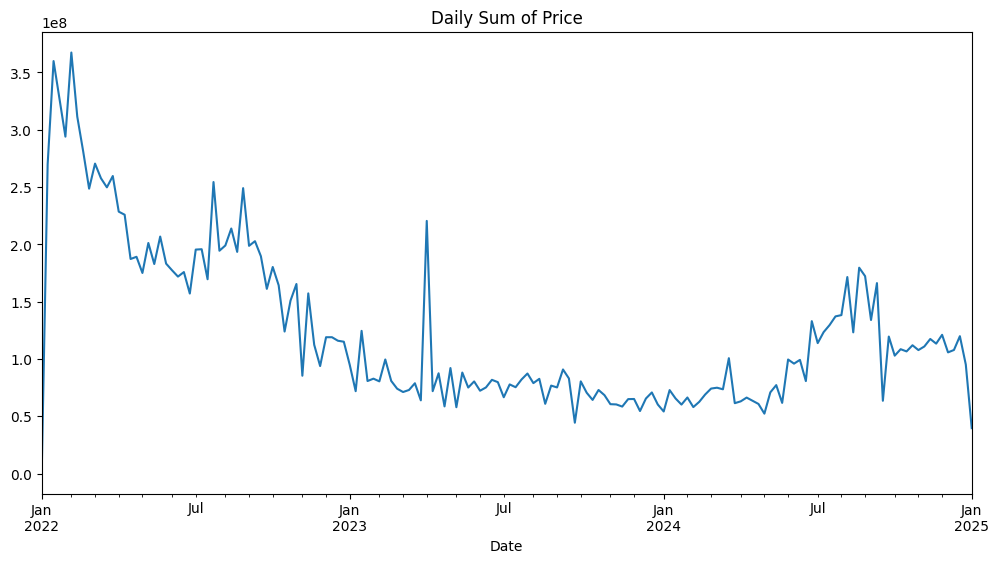

In [130]:
daily_sum = df["FLETE_POR_BULTO"].resample("W").sum()
print(daily_sum.size)
daily_sum.plot(figsize=(12, 6))
plt.title("Daily Sum of Price")
plt.xlabel("Date")
plt.show()